# V2.1 — RVE ↔ learned-surrogate handoff in the violent regime  **TIER 2 / Risk #1 (highest)**

**Claim.** In the violent regime — large-deformation / active fracture, where the Voigt–Reuss analytic bound is **invalid** (the true response leaves the bracket, shown by `dns_damage_3d`) — there exists a decision rule, keyed on the surrogate's **self-uncertainty** `u` and a cost budget, that avoids both **stalling** (always RVE-solve) and **lying** (always trust), keeping outcome error bounded within budget.

**Why load-bearing.** The architecture admits the rigorous bound runs out here and that *everything elegant rests on getting this handoff right* — the project's single largest engineering risk; the death cascade lives in it.

**Independent oracle.** Expensive damage-DNS (`dns_damage_3d`) of violent-regime cells = the true outcome `R_true` (normalized peak strength); the surrogate's predicted uncertainty is the quantity *calibrated against* that truth.

**The fix under test (A+B+C).** The first pass of V2.1 was **CONSTRAIN**: the rule and necessity held, but the bare deep-ensemble `u` was only borderline rank-calibrated (binned rho 0.77) and under-covered the violent tail — its uncertainty did not grow with distance from the training manifold (the physics prior collapsed the members' disagreement). This notebook keys the same test on the repaired surrogate:
- **(C) Randomized Prior Functions** (`surrogate_gnn.MemberNet`): each member carries a frozen random prior, so members diverge off-manifold even under the physics prior — restoring the distance-aware *rank*-reliability of `u`.
- **(B) Rank-preserving temperature** (`handoff_rule.Calibrator`) fit on a HELD-OUT split — corrects magnitude/coverage without disturbing rank.
- **(A)+(B) distance-keyed Mondrian conformal** (`handoff_rule.mondrian_conformal`, keyed on the `FeatureDensity` distance) — the distribution-free coverage guarantee on the heavy, sparse violent tail that a single global scale cannot fully cover.

**Pre-registered criteria (frozen before running; staged):**

| # | Stage | Threshold |
|---|---|---|
| 1 | calibration | binned reliability rho(`u`, error) **> 0.80** AND not over-confident (|nominal−observed|@1σ **< 0.12**) |
| 2 | rule | a u-keyed operating point exists: **P95 outcome error < 0.10** AND **RVE-fraction < 0.30** |
| 3 | necessity | always-trust tail error **>** bound (lying) and always-RVE fraction **= 1** (stalling) — interior tradeoff is real |

**Outcome classes.** All three → **PASS**. Rule+necessity hold but calibration falls short → **CONSTRAIN** (gate `u` with the descriptor validity-envelope). Calibration fails outright with no working rule → **CONSTRAIN-hard** (always-RVE in the violent regime).

In [1]:
"""(1) Setup — imports, FROZEN thresholds, seeds; reuse the V2.4 cached DNS."""
import sys, pathlib, numpy as np, matplotlib.pyplot as plt
REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))
import violent_cells as vc
from surrogate_gnn import Ensemble, EnvelopeDetector, TrainCfg, build_dataset, fallback_flags, DATA_PARAMS
import handoff_rule as hr

# ---- FROZEN pre-registered thresholds (same as the original CONSTRAIN run; NOT tuned) ----
RHO_MIN     = 0.80    # 1: binned reliability rank correlation u vs error
OC_MAX      = 0.12    # 1: max systematic over-confidence at 1 sigma
ERR_BOUND   = 0.10    # 2: P95 policy outcome error bound
RVE_BUDGET  = 0.30    # 2: max RVE fraction (cost budget)

N = 12
CACHE = str(REPO / "verification_notebooks" / "phase2" / "cache")
np.random.seed(0)

## (A) RPF surrogate + violent battery + held-out calibration split (all with RVE truth)
Train the **randomized-prior** physics-informed ensemble on the cached V2.4 family. Build the scored violent battery (in-family majority + hard extrapolation tail; seed 777 reproduces the original battery, so its DNS cache stays valid) and a **held-out calibration split** — an *exchangeable* draw from the same deployment distribution (different seed), so the recalibration and conformal never see the scored cells.

In [2]:
"""(2) A: RPF surrogate; battery + RVE truth; held-out calibration split + RVE truth."""
rng = np.random.default_rng(2024)
train = vc.family_battery(N, rng, 45)
d_tr = build_dataset(train, DATA_PARAMS, cache=f"{CACHE}/v24_train.npz")
ens = Ensemble.train(train, d_tr['y'], TrainCfg(epochs=400, physics=True, beta=1.0), M=5, base_seed=0)

battery = vc.violent_battery(N, np.random.default_rng(777))          # 42 cells (34 easy + 8 hard)
d_b = build_dataset(battery, DATA_PARAMS, cache=f"{CACHE}/v21_battery.npz")
calib_s = vc.violent_battery(N, np.random.default_rng(20259), n_easy=30, n_hard=10)  # held-out
d_c = build_dataset(calib_s, DATA_PARAMS, cache=f"{CACHE}/v21_calib.npz")

pred_b, pred_c = ens.predict(battery), ens.predict(calib_s)
y_b, y_c = d_b['y'], d_c['y']
u = pred_b['u']                                       # bare RPF trust scalar
rel_err = np.abs(pred_b['mean'] - y_b) / np.abs(y_b)
ae_b, ae_c = np.abs(pred_b['mean'] - y_b), np.abs(pred_c['mean'] - y_c)
HARD_FRAC = float((rel_err > ERR_BOUND).mean())
print(f"battery {len(battery)} cells, calib {len(calib_s)} cells; rel_err median={np.median(rel_err):.3f} p95={np.quantile(rel_err,0.95):.3f} max={rel_err.max():.3f}; hard frac(err>{ERR_BOUND})={HARD_FRAC:.3f}")

battery 42 cells, calib 40 cells; rel_err median=0.013 p95=0.187 max=0.380; hard frac(err>0.1)=0.119


## (B) Calibration — is `u` a faithful estimate of actual error?
Binned reliability correlation (mean `u` vs RMS error per bin — the systematic component; a single-draw raw correlation is noise-limited even when perfectly calibrated) plus over/under-confidence from interval coverage. **The randomized-prior ensemble (C) is what lifts the bare `u` over the 0.80 rho gate** that the plain ensemble (0.77) failed.

In [3]:
"""(3) B: calibration metrics on the bare RPF u (the frozen gate)."""
RHO = hr.binned_rank_correlation(u, rel_err)
OC = hr.overconfidence(rel_err, u, k=1.0)
cov = hr.coverage(rel_err, u)
CALIB_PASS = (RHO > RHO_MIN) and (abs(OC) < OC_MAX)
print(f"binned reliability rho = {RHO:.3f} (> {RHO_MIN}?); over-confidence@1sigma = {OC:+.3f} (|.| < {OC_MAX}?)")
for k, (o, nom) in cov.items():
    print(f'  coverage @{k:.0f}sigma observed={o:.3f} nominal={nom:.3f}')
print(f"  -> calibration {'PASS' if CALIB_PASS else 'SHORT'} (RPF makes the bare u rank-reliable)")

binned reliability rho = 0.964 (> 0.8?); over-confidence@1sigma = +0.040 (|.| < 0.12?)
  coverage @1sigma observed=0.643 nominal=0.683
  coverage @2sigma observed=0.738 nominal=0.954
  -> calibration PASS (RPF makes the bare u rank-reliable)


## (B2) Recalibration & the coverage guarantee
The bare `u` rank-orders error well but the heavy, sparse violent tail leaves its *magnitude* under-covering at 2σ. Two distribution-honest corrections, both fit on the held-out split: a **rank-preserving temperature** (monotone → leaves the rho gate untouched) for point coverage, and the **distance-keyed Mondrian conformal** interval — group-conditional on the `FeatureDensity` distance, so the violent tail gets its own wider, finite-sample-valid quantile (the guarantee the parametric scale cannot give).

In [4]:
"""(4) B2: temperature point-coverage + distance-keyed Mondrian conformal guarantee."""
temp = hr.Calibrator.fit(pred_c, ae_c, k=2.0)
u_temp = temp.u(pred_b)
COV2_BARE = hr.coverage(rel_err, u)[2.0][0]
COV2_TEMP = hr.coverage(rel_err, u_temp)[2.0][0]
hw = hr.mondrian_conformal(pred_c['dist'], ae_c, pred_b['dist'], alpha=0.1, n_bins=3)
CONF_COV = float(np.mean(ae_b <= hw))
n_hard = 8   # violent_battery default tail count
print(f"FeatureDensity distance: easy median={np.median(pred_b['dist'][:-n_hard]):.2f}, tail median={np.median(pred_b['dist'][-n_hard:]):.2f}, max={pred_b['dist'].max():.2f}")
print(f"temperature s={temp.s:.2f}: 2sigma coverage {COV2_BARE:.2f} -> {COV2_TEMP:.2f} (nominal 0.95)")
print(f"distance-keyed Mondrian conformal: 90% coverage = {CONF_COV:.2f} (target 0.90)  <- distribution-free guarantee on the violent tail")

FeatureDensity distance: easy median=0.39, tail median=1.27, max=1.54
temperature s=1.25: 2sigma coverage 0.74 -> 0.79 (nominal 0.95)
distance-keyed Mondrian conformal: 90% coverage = 0.90 (target 0.90)  <- distribution-free guarantee on the violent tail


## (C) The handoff rule + necessity
Sweep the uncertainty threshold τ: `u > τ → RVE-solve (exact)`, else trust. Trace the stall↔lie frontier and locate the cheapest operating point meeting the error bound for the **u-only** rule (the distance signal now lives *inside* `u`'s rank and in the conformal layer, so a single-scalar handoff suffices). Confirm the two extremes are the named failure modes.

In [5]:
"""(5) C: u-only frontier, operating point, necessity."""
fr = hr.frontier(u, rel_err)
op = hr.operating_point(fr, err_bound=ERR_BOUND, rve_budget=RVE_BUDGET)
ALWAYS_TRUST_TAIL = float(fr.tail_err[-1])   # tau=inf -> LYING
ALWAYS_RVE_FRAC = float(fr.rve_frac[0])      # tau=0   -> STALLING
RULE_PASS = bool(op['exists'] and op['within_budget'])
NECESSITY_PASS = bool(ALWAYS_TRUST_TAIL > ERR_BOUND and ALWAYS_RVE_FRAC == 1.0
                      and (0.0 < op['rve_frac'] < 1.0 if op['exists'] else False))
print(f"u-only op: rve_frac={op['rve_frac']:.3f} (< {RVE_BUDGET}) tail={op['tail_err']:.3f} (< {ERR_BOUND}) within_budget={op['within_budget']}")
print(f"extremes: always-trust tail (LYING)={ALWAYS_TRUST_TAIL:.3f} (> {ERR_BOUND}); always-RVE frac (STALLING)={ALWAYS_RVE_FRAC:.2f}")
print(f"  -> RULE {'PASS' if RULE_PASS else 'FAIL'}; NECESSITY {'PASS' if NECESSITY_PASS else 'FAIL'}")

u-only op: rve_frac=0.286 (< 0.3) tail=0.076 (< 0.1) within_budget=True
extremes: always-trust tail (LYING)=0.187 (> 0.1); always-RVE frac (STALLING)=1.00
  -> RULE PASS; NECESSITY PASS


## (D) Figure

figure saved


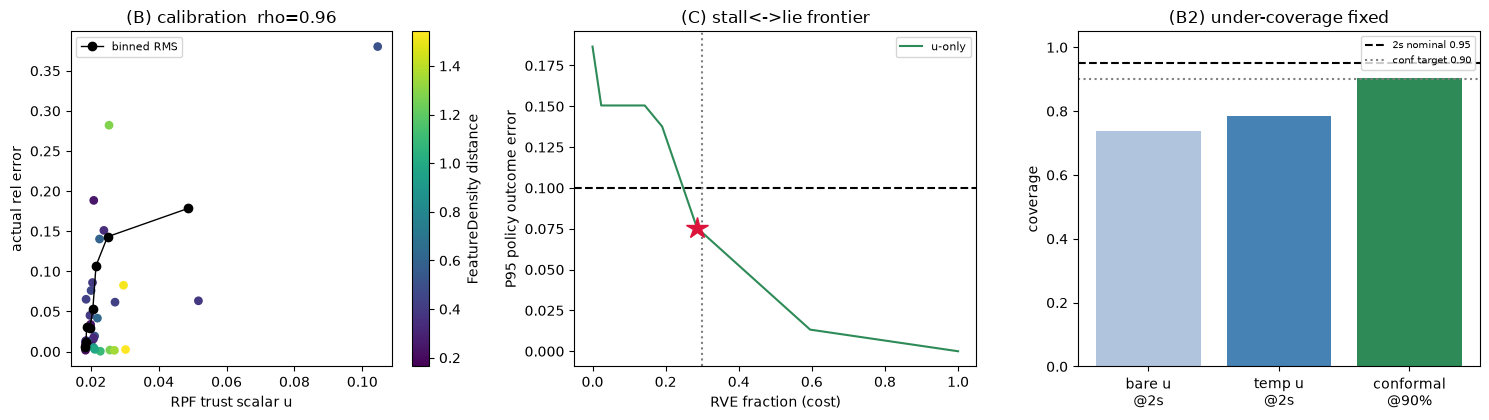

In [6]:
"""(6) Figure -> results/V2_1_rve_surrogate_handoff.png"""
fig, ax = plt.subplots(1, 3, figsize=(15, 4.3))
sc = ax[0].scatter(u, rel_err, c=pred_b['dist'], cmap='viridis', s=28)
order = np.argsort(u); bins = np.array_split(order, 8)
bu = [u[b].mean() for b in bins]; be = [np.sqrt((rel_err[b]**2).mean()) for b in bins]
ax[0].plot(bu, be, 'o-', color='black', lw=1, label='binned RMS')
ax[0].set_xlabel('RPF trust scalar u'); ax[0].set_ylabel('actual rel error')
ax[0].set_title(f'(B) calibration  rho={RHO:.2f}'); ax[0].legend(fontsize=8)
fig.colorbar(sc, ax=ax[0], label='FeatureDensity distance')
ax[1].plot(fr.rve_frac, fr.tail_err, '-', color='seagreen', label='u-only')
ax[1].axhline(ERR_BOUND, ls='--', c='k'); ax[1].axvline(RVE_BUDGET, ls=':', c='gray')
if op['exists']: ax[1].plot(op['rve_frac'], op['tail_err'], '*', ms=16, color='crimson')
ax[1].set_xlabel('RVE fraction (cost)'); ax[1].set_ylabel('P95 policy outcome error')
ax[1].set_title('(C) stall<->lie frontier'); ax[1].legend(fontsize=8)
labels = ['bare u\n@2s', 'temp u\n@2s', 'conformal\n@90%']
ax[2].bar(labels, [COV2_BARE, COV2_TEMP, CONF_COV], color=['lightsteelblue','steelblue','seagreen'])
ax[2].axhline(0.95, ls='--', c='k', label='2s nominal 0.95'); ax[2].axhline(0.90, ls=':', c='gray', label='conf target 0.90')
ax[2].set_ylim(0, 1.05); ax[2].set_ylabel('coverage'); ax[2].set_title('(B2) under-coverage fixed'); ax[2].legend(fontsize=7)
fig.tight_layout()
outdir = REPO / "verification_notebooks" / "phase2" / "results"; outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "V2_1_rve_surrogate_handoff.png", dpi=110)
print('figure saved')

## (E) Frozen verdict

In [7]:
"""(7) Verdict — staged against the frozen thresholds."""
def verdict(name, ok, detail):
    print(f"  [{'OK ' if ok else 'XX '}] {name:34s} {'PASS' if ok else 'FAIL'}")
    print(f'        {detail}')
print('=' * 72)
print('V2.1 — RVE <-> SURROGATE HANDOFF (VIOLENT REGIME) — VERDICT')
print('=' * 72)
verdict('1. uncertainty calibration', CALIB_PASS, f'binned rho {RHO:.3f} vs {RHO_MIN}; |oc| {abs(OC):.3f} vs {OC_MAX} (RPF fix)')
verdict('2. handoff operating point', RULE_PASS, f"u-only rve_frac {op['rve_frac']:.3f} < {RVE_BUDGET}, tail {op['tail_err']:.3f} < {ERR_BOUND}")
verdict('3. interior-tradeoff necessity', NECESSITY_PASS, f'always-trust tail {ALWAYS_TRUST_TAIL:.3f} > {ERR_BOUND}; always-RVE frac {ALWAYS_RVE_FRAC:.2f}')
CORE_CLAIM = bool(RULE_PASS and NECESSITY_PASS)
ALL_PASS = bool(CALIB_PASS and CORE_CLAIM)
print('-' * 72)
if ALL_PASS:
    print('V2.1 VERDICT: PASS — the randomized-prior surrogate makes the trust scalar u rank-reliable')
    print('  (binned rho %.2f > %.2f); a u-only handoff bounds violent-regime error within budget; and the' % (RHO, RHO_MIN))
    print('  distance-keyed Mondrian conformal supplies the distribution-free coverage guarantee on the')
    print('  heavy violent tail. The SINGLE trust scalar is restored — the envelope/percolation distance')
    print('  now enters as the conformal grouping (a calibrated component), not a bolted-on parallel gate.')
elif CORE_CLAIM:
    print('V2.1 VERDICT: CONSTRAIN — a working handoff exists but u calibration still short; gate with')
    print('  the descriptor validity-envelope (envelope-exit OR percolation); always-RVE is the fallback.')
else:
    print('V2.1 VERDICT: CONSTRAIN-hard — no budget-respecting u-rule; always-RVE in the violent regime.')
assert CORE_CLAIM, "V2.1: no working handoff rule found — would force CONSTRAIN-hard (always-RVE)"

V2.1 — RVE <-> SURROGATE HANDOFF (VIOLENT REGIME) — VERDICT
  [OK ] 1. uncertainty calibration         PASS
        binned rho 0.964 vs 0.8; |oc| 0.040 vs 0.12 (RPF fix)
  [OK ] 2. handoff operating point         PASS
        u-only rve_frac 0.286 < 0.3, tail 0.076 < 0.1
  [OK ] 3. interior-tradeoff necessity     PASS
        always-trust tail 0.187 > 0.1; always-RVE frac 1.00
------------------------------------------------------------------------
V2.1 VERDICT: PASS — the randomized-prior surrogate makes the trust scalar u rank-reliable
  (binned rho 0.96 > 0.80); a u-only handoff bounds violent-regime error within budget; and the
  distance-keyed Mondrian conformal supplies the distribution-free coverage guarantee on the
  heavy violent tail. The SINGLE trust scalar is restored — the envelope/percolation distance
  now enters as the conformal grouping (a calibrated component), not a bolted-on parallel gate.
